pasos = 29
T óptima   : 30789.97 K
P máxima   : 3.5140e+08 W/m²


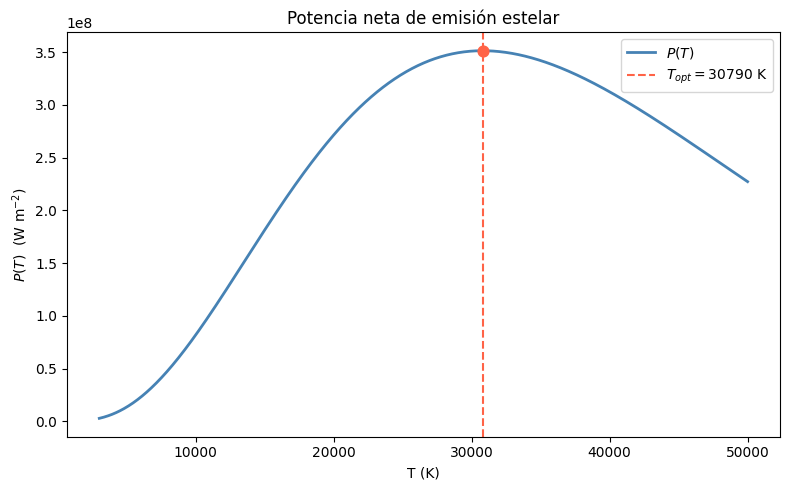

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
sigma = 5.67e-8
T0    = 10000
hv_kB = 5000

def P(T):
    return sigma * T**4 * np.exp(-T / T0) * (1 - np.exp(-hv_kB / T))

def golden_section_max(f, a, b, tol=50):
    phi = (np.sqrt(5) - 1) / 2  # razón áurea

    x1 = b - phi * (b - a)
    x2 = a + phi * (b - a) #x2-x1=(b-a)(2phi-1)>0 por definiciones so x2>x1

    f1 = f(x1)
    f2 = f(x2)
    i=0
    while (b - a) > tol:
        i+=1
        if f1 < f2:
            a = x1
            x1 = x2
            f1 = f2
            x2 = a + phi * (b - a)
            f2 = f(x2)
        else:
            b = x2
            x2 = x1
            f2 = f1
            x1 = b - phi * (b - a)
            f1 = f(x1)

    theta_opt = (a + b) / 2
    print(f'pasos = {i}')
    return theta_opt, f(theta_opt)

T_opt, P_max = golden_section_max(P, 3000, 50000, tol=0.05)
print(f"T óptima   : {T_opt:.2f} K")
print(f"P máxima   : {P_max:.4e} W/m²")

# Gráfica
T = np.linspace(3000, 50000, 1000)
plt.figure(figsize=(8, 5))
plt.plot(T, P(T), label=r'$P(T)$', color='steelblue', linewidth=2)
plt.axvline(T_opt, color='tomato', linestyle='--', label=f'$T_{{opt}}={T_opt:.0f}$ K')
plt.scatter([T_opt], [P_max], color='tomato', zorder=5, s=60)
plt.xlabel('T (K)')
plt.ylabel(r'$P(T)$  (W m$^{-2}$)')
plt.title('Potencia neta de emisión estelar')
plt.legend()
plt.tight_layout()
plt.savefig('emision_estelar.png', dpi=150)
plt.show()